### What are the key factors that predict fraudulent customer?

Your model has identified these as key predictors: amount, oldbalanceDest, newbalanceOrig, type (e.g., CASH_OUT, TRANSFER), isFraud

#### Do these factors make sense? If yes, how?

Yes — each factor logically contributes to predicting fraud, including type:

Feature	   ---     Why It Makes Sense

amount	---        Large, sudden transfers are a common fraud tactic.

oldbalanceDest	---Zero balance before receiving money could indicate a newly opened or mule account.

newbalanceOrig	---Sudden drops to zero can be a red flag, especially after high-value transfers.

type        	---Certain types like TRANSFER and CASH_OUT are high-risk compared to PAYMENT.

### What kind of prevention should be adopted while the company updates its infrastructure?

Here's a targeted prevention strategy based on these features:

Factor	---Prevention Tactic

amount	---Set adaptive thresholds for transaction value, and flag high-volume accounts.

type	---Apply stricter rules on TRANSFER and CASH_OUT transactions.

oldbalanceDest = 0	---Flag destinations that receive large sums but had zero balance.

newbalanceOrig = 0---	Alert when origin accounts are drained completely after transaction.

Combined check	----Block or verify when TRANSFER/CASH_OUT + large amount + destination=0.

### Assuming these actions have been implemented, how would you determine if they work?

Track these effectiveness indicators:

Metric	---What It Tells You
🔍 Precision & Recall	---Are you catching more frauds without many false alarms?

📉 Drop in fraud losses---	Compare monetary fraud loss before and after implementation.

🔄 False Positive Rate---	Are you wrongly flagging real users?

✅ AUC-ROC Score---	Overall model discriminative ability.

🧪 A/B Testing---	Test infrastructure with vs. without rules on type + amount, etc.

👥 User Trust Feedback	---Survey or support ticket trends can reveal user satisfaction.

In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# Loading Dataset:
df = pd.read_csv("Fraud.csv.csv")
# Reading top 4 records
df.head(4)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0


In [29]:
# shape of dataset
df.shape

(954367, 11)

In [30]:
# names of columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [31]:
#get information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954367 entries, 0 to 954366
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            954367 non-null  int64  
 1   type            954367 non-null  object 
 2   amount          954367 non-null  float64
 3   nameOrig        954367 non-null  object 
 4   oldbalanceOrg   954367 non-null  float64
 5   newbalanceOrig  954367 non-null  float64
 6   nameDest        954366 non-null  object 
 7   oldbalanceDest  954366 non-null  float64
 8   newbalanceDest  954366 non-null  float64
 9   isFraud         954366 non-null  float64
 10  isFlaggedFraud  954366 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 80.1+ MB


### In this Dataset ,  there are no missing value  . So we dont need to handle missing value  

In [32]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,954367.000000,9.543670e+05,9.543670e+05,9.543670e+05,9.543660e+05,9.543660e+05,954366.000000,954366.0
mean,24.238798,1.620137e+05,8.821374e+05,9.028888e+05,9.873469e+05,1.130359e+06,0.000535,0.0
std,12.217524,2.609846e+05,2.995072e+06,3.031947e+06,2.307988e+06,2.431987e+06,0.023133,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,14.000000,1.300857e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,19.000000,8.075746e+04,1.604800e+04,0.000000e+00,1.353167e+05,2.328761e+05,0.000000,0.0
75%,37.000000,2.190550e+05,1.429053e+05,1.833698e+05,9.269566e+05,1.174360e+06,0.000000,0.0
max,44.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.205466e+07,1.000000,0.0


In [33]:
# find out the number of null values in each columns
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [34]:
# Exploring transaction type
print(df.type.value_counts())

type
CASH_OUT    347183
PAYMENT     313148
CASH_IN     209229
TRANSFER     78671
DEBIT         6136
Name: count, dtype: int64


In [35]:
import plotly.express as px
# Get value counts
type_counts = df["type"].value_counts().reset_index()
type_counts.columns = ['Transaction Type', 'Count']

# Plot
figure = px.pie(type_counts,
                names='Transaction Type',
                values='Count',
                hole=0.5,
                title="Distribution of Transaction Type")
figure.show()

### Treat Multicollinearity

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def calculate_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

# Drop non-numeric columns and handle NaNs
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Scale features to improve stability
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# Calculate VIF
vif_df = calculate_vif(df_scaled)
print(vif_df)

        variables         VIF
0            step    1.008624
1          amount    1.415590
2   oldbalanceOrg  739.042653
3  newbalanceOrig  741.455149
4  oldbalanceDest   31.183640
5  newbalanceDest   32.712948
6         isFraud    1.047635
7  isFlaggedFraud         NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning:

invalid value encountered in scalar divide



In [37]:
# The below two columns are highly multicollinearity . so , we drop them.
df = df.drop(columns=['oldbalanceOrg'])
df = df.drop(columns=['newbalanceDest'])


In [38]:
# Multicollinearity after droping the highly related column

# Drop non-numeric columns and handle NaNs
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Scale features to improve stability
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# Calculate VIF
vif_df = calculate_vif(df_scaled)
print(vif_df)

        variables       VIF
0            step  1.000254
1          amount  1.054829
2  newbalanceOrig  1.009582
3  oldbalanceDest  1.058708
4         isFraud  1.005568
5  isFlaggedFraud       NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning:

invalid value encountered in scalar divide



### Treat outlier

In [39]:
# convert categorical data into numeric
df["type"] = df["type"].map({"CASH_OUT": 1, "PAYMENT": 2,
                                 "CASH_IN": 3, "TRANSFER": 4,
                                 "DEBIT": 5})


print(df.head())

   step  type    amount     nameOrig  newbalanceOrig     nameDest  \
0     1     2   9839.64  C1231006815       160296.36  M1979787155   
1     1     2   1864.28  C1666544295        19384.72  M2044282225   
2     1     4    181.00  C1305486145            0.00   C553264065   
3     1     1    181.00   C840083671            0.00    C38997010   
4     1     2  11668.14  C2048537720        29885.86  M1230701703   

   oldbalanceDest  isFraud  isFlaggedFraud  
0             0.0      0.0             0.0  
1             0.0      0.0             0.0  
2             0.0      1.0             0.0  
3         21182.0      1.0             0.0  
4             0.0      0.0             0.0  


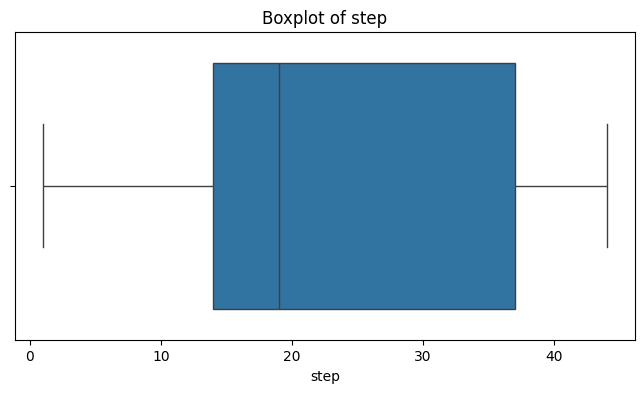

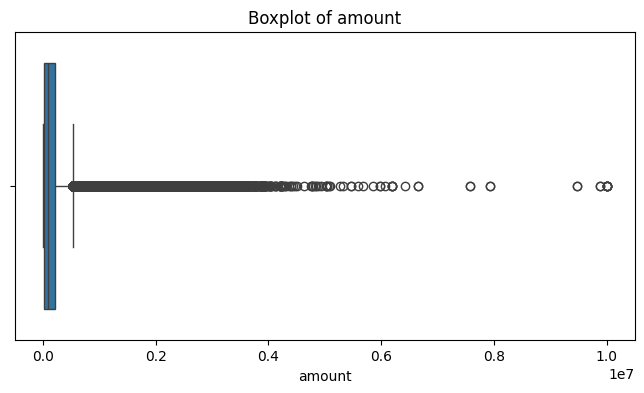

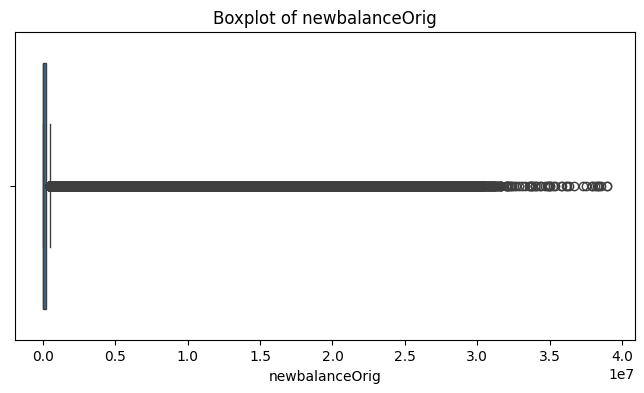

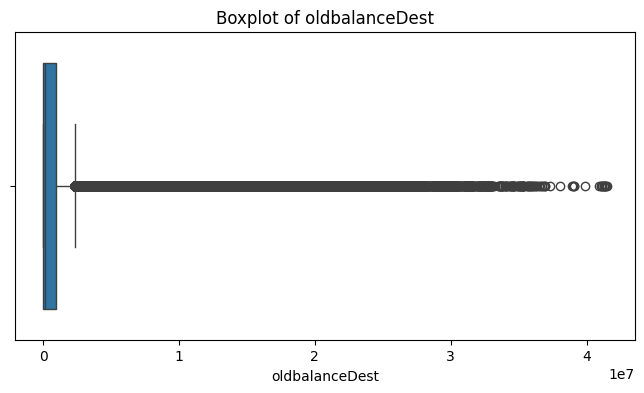

In [40]:
# Visualize outliers for each numeric column
numeric_cols = ['step','amount',  'newbalanceOrig', 'oldbalanceDest']
#df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [41]:
# appling caping
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df

# Apply to all numeric columns
df_capped = df.copy()
for col in numeric_cols:
    df_capped = cap_outliers_iqr(df_capped, col)

print("Shape after outlier capping:", df_capped.shape)


Shape after outlier capping: (954367, 9)


In [42]:
# Treat outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to all numeric columns
df_cleaned = df.copy()
for col in numeric_cols:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print("Shape after outlier removal:", df_cleaned.shape)


Shape after outlier removal: (661142, 9)


Why Capping is Better Here:

Keeps all rows in the dataset.

Reduces the influence of extreme outlier values.

Retains statistical power, which is useful for rare-event modeling like fraud detection.


In [43]:
# Appling capping to the dataset
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping using np.where
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df

In [44]:
df_capped = df.copy()  # Preserve the original data

for col in numeric_cols:
    df_capped = cap_outliers_iqr(df_capped, col)


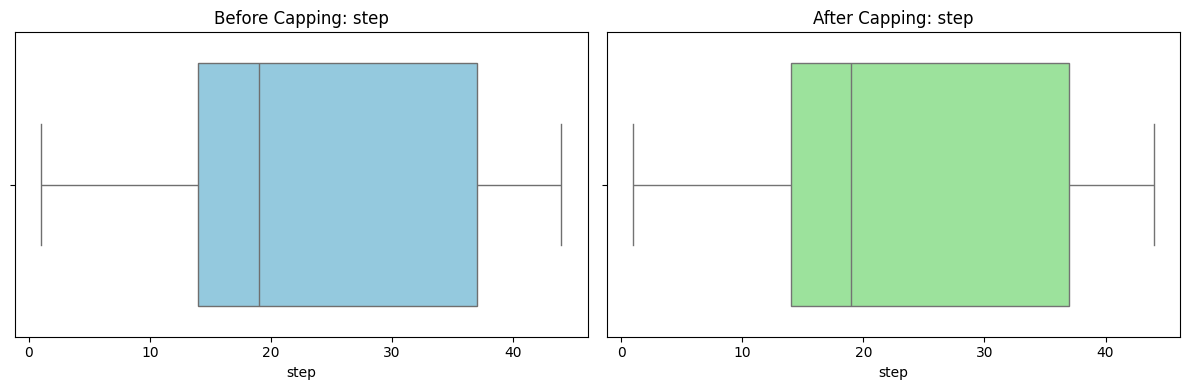

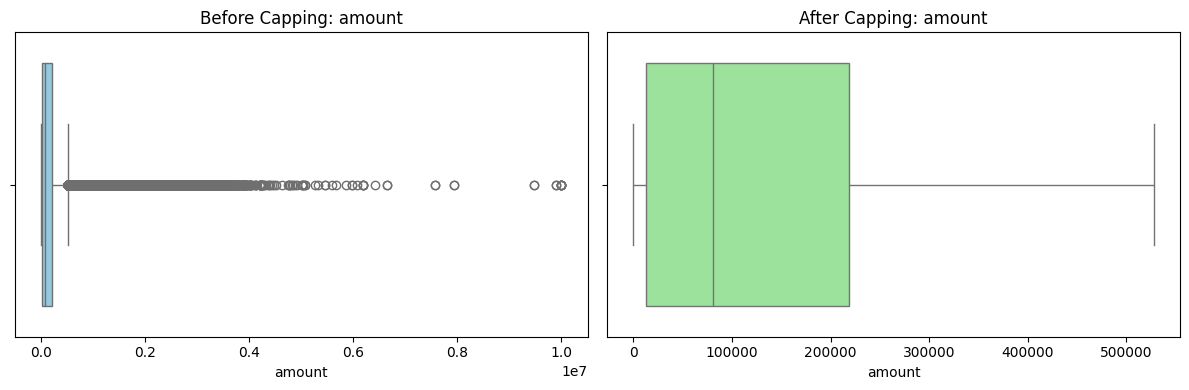

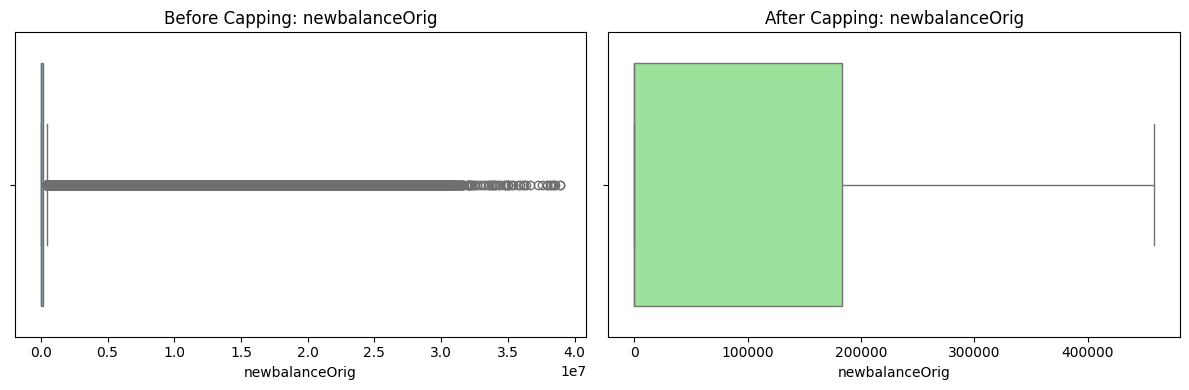

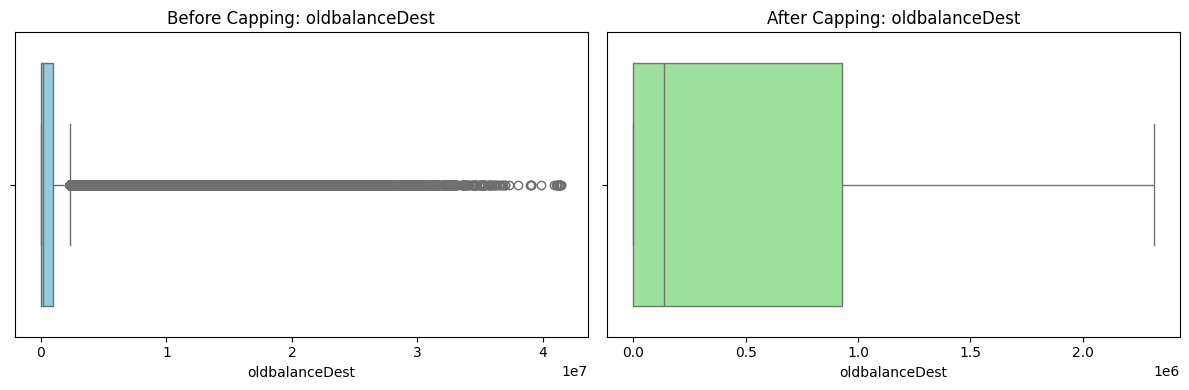

In [45]:
for col in numeric_cols:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Before Capping: {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_capped[col], color='lightgreen')
    plt.title(f'After Capping: {col}')

    plt.tight_layout()
    plt.show()


### spiltting the dataset

In [46]:
# Spiltting the dataset
from sklearn.model_selection import train_test_split

# Drop multiple columns correctly by passing a list
X = df_capped.drop(["isFraud", "nameDest", "step", "nameOrig", "isFlaggedFraud"], axis=1).values

# Target variable
y = df_capped["isFraud"].values


In [47]:
# training a machine learning model
from sklearn.tree import DecisionTreeClassifier
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.10, random_state=42)

In [48]:
import numpy as np

print(np.isnan(ytrain).sum())

1


In [49]:
mask = ~np.isnan(ytrain)

xtrain = xtrain[mask]
ytrain = ytrain[mask]

In [50]:
print(np.isnan(ytrain).sum())

0


In [51]:
# Install
!pip install imbalanced-learn

# Imports
import numpy as np
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, roc_auc_score

# 🔹 Apply SMOTE
smote = SMOTE(random_state=42)
xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)

# 🔹 Scaling
scaler = StandardScaler()
xtrain_smote = scaler.fit_transform(xtrain_smote)
xtest_scaled = scaler.transform(xtest)

# 🔥 Use subset for tuning (FAST)
idx = np.random.choice(len(xtrain_smote), size=100000, replace=False)
x_sample = xtrain_smote[idx]
y_sample = ytrain_smote[idx]

# =====================================================
# 🔥 Logistic Regression
# =====================================================
param_lr = {'C': [0.01, 0.1, 1, 10]}

lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)
lr.fit(x_sample, y_sample)

# =====================================================
# 🔥 Decision Tree
# =====================================================
param_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

dt = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_dt,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)
dt.fit(x_sample, y_sample)

# =====================================================
# 🔥 Random Forest (MOST IMPORTANT)
# =====================================================
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2']
}

rf = RandomizedSearchCV(
    RandomForestClassifier(),
    param_rf,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(x_sample, y_sample)

# =====================================================
# 🔥 Gradient Boosting
# =====================================================
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

gb = RandomizedSearchCV(
    GradientBoostingClassifier(),
    param_gb,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)
gb.fit(x_sample, y_sample)

# =====================================================
# 🔥 Naive Bayes (no tuning needed)
# =====================================================
nb = GaussianNB()
nb.fit(xtrain_smote, ytrain_smote)

# =====================================================
# 🔥 Evaluate All Models
# =====================================================
best_models = {
    "Logistic Regression": lr.best_estimator_,
    "Decision Tree": dt.best_estimator_,
    "Random Forest": rf.best_estimator_,
    "Gradient Boosting": gb.best_estimator_,
    "Naive Bayes": nb
}

for name, model in best_models.items():
    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)

    # Train on full data
    model.fit(xtrain_smote, ytrain_smote)

    # Predict
    y_pred = model.predict(xtest_scaled)
    y_prob = model.predict_proba(xtest_scaled)[:, 1]

    print("Classification Report:\n", classification_report(ytest, y_pred))
    print("ROC-AUC Score:", roc_auc_score(ytest, y_prob))


MODEL: Logistic Regression
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.81      0.90     95380
         1.0       0.00      0.74      0.00        57

    accuracy                           0.81     95437
   macro avg       0.50      0.78      0.45     95437
weighted avg       1.00      0.81      0.90     95437

ROC-AUC Score: 0.8324408736246152

MODEL: Decision Tree
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     95380
         1.0       0.01      0.65      0.02        57

    accuracy                           0.95     95437
   macro avg       0.50      0.80      0.49     95437
weighted avg       1.00      0.95      0.97     95437

ROC-AUC Score: 0.9111134409729502

MODEL: Random Forest
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.98     95380
         1.0       0.01  

In [52]:
# ==============================
# 1. IMPORTS
# ==============================
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ==============================
# 2. APPLY SMOTE
# ==============================
smote = SMOTE(random_state=42)
xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)

# ==============================
# 3. FEATURE SCALING
# ==============================
scaler = StandardScaler()
xtrain_smote = scaler.fit_transform(xtrain_smote)
xtest_scaled = scaler.transform(xtest)

# ==============================
# 4. SAMPLE FOR FAST TUNING
# ==============================
idx = np.random.choice(len(xtrain_smote), size=100000, replace=False)
x_sample = xtrain_smote[idx]
y_sample = ytrain_smote[idx]

# ==============================
# 5. HYPERPARAMETER TUNING
# ==============================
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gb = RandomizedSearchCV(
    GradientBoostingClassifier(),
    param_gb,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

gb.fit(x_sample, y_sample)

print("Best Parameters:", gb.best_params_)

# ==============================
# 6. TRAIN FINAL MODEL
# ==============================
final_model = gb.best_estimator_
final_model.fit(xtrain_smote, ytrain_smote)

# ==============================
# 7. PREDICTION
# ==============================
y_pred = final_model.predict(xtest_scaled)
y_prob = final_model.predict_proba(xtest_scaled)[:, 1]

# ==============================
# 8. EVALUATION
# ==============================
print("\nClassification Report:\n", classification_report(ytest, y_pred))
print("ROC-AUC Score:", roc_auc_score(ytest, y_prob))

Best Parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     95380
         1.0       0.01      0.65      0.01        57

    accuracy                           0.95     95437
   macro avg       0.50      0.80      0.49     95437
weighted avg       1.00      0.95      0.97     95437

ROC-AUC Score: 0.9388447134821747


In [53]:
import joblib

# Save model
joblib.dump(final_model, "fraud_model.pkl")

['fraud_model.pkl']